# Three-Group DEG Analysis + Literature Confidence Scoring: ER+ / ER- / Normal (TCGA-BRCA)
**Design:** instead of comparing ER+ directly to ER-, we compare each subtype to normal breast tissue (TCGA Solid Tissue Normal) and classify genes by dysregulation origin (Li et al. 2013):
- Class 1: dysregulated same direction in both subtypes
- Class 2: **oppositely** dysregulated (primary target)
- Class 3 / 4: dysregulated only in ER+ or only in ER-

Three methods (DESeq2, edgeR, limma-voom) with order-safe rpy2 handoff; consensus = all three agree. **Novel layer:** automated PubMed literature scoring (with synonym resolution) separates reproducible-and-known from reproducible-but-understudied Class-2 genes.

NOTE: normal samples are downloaded in section 2; rerun the full data section (don't use the old two-group cache).

# 1. Environment setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
SAVE_DIR = '/content/drive/MyDrive/TCGA_BRCA_Project'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory: {SAVE_DIR}')

# Auto-cache flag with VALIDATION: the cache is only trusted if the filtered matrix and
# the metadata exist AND actually agree (every matrix column has a metadata row with the
# right key). If they came from different runs, the cache is auto-invalidated and the
# data section rebuilds from scratch - no manual file deletion needed.
_cf = f'{SAVE_DIR}/count_filtered.parquet'
_sm = f'{SAVE_DIR}/sample_metadata.csv'
_DATA_READY = False
if os.path.exists(_cf) and os.path.exists(_sm):
    try:
        _cols = pd.read_parquet(_cf).columns
        _meta = pd.read_csv(_sm)
        _key = 'sample_key' if 'sample_key' in _meta.columns else 'case_id'
        _ids = set(_meta[_key].astype(str))
        _missing = [c for c in _cols if str(c) not in _ids]
        if not _missing and 'condition' in _meta.columns:
            _DATA_READY = True
            print(f'Valid cache found: {len(_cols)} samples, keys aligned. Skipping download.')
        else:
            print(f'Cache INVALID ({len(_missing)} matrix cols not in metadata, or no condition col).')
            print('Auto-rebuilding data from scratch - no action needed.')
    except Exception as e:
        print('Cache check failed, will rebuild:', e)
else:
    print('No cache present - will download data.')
print('Cached data usable:', _DATA_READY)


Mounted at /content/drive
Save directory: /content/drive/MyDrive/TCGA_BRCA_Project
No cache present - will download data.
Cached data usable: False


In [ ]:
# ── Install all dependencies (run once, then restart runtime) ──────────────
import subprocess, sys

packages = [
    'pydeseq2',
    'requests',
    'matplotlib',
    'seaborn',
    'scipy',
    'statsmodels',
    'matplotlib-venn',
    'gseapy',
    'anthropic',
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Install R packages via rpy2 (edgeR, limma)
import rpy2.robjects as ro
ro.r('''
if (!require('BiocManager', quietly=TRUE)) install.packages('BiocManager', repos='https://cloud.r-project.org')
BiocManager::install(c('edgeR', 'limma'), update=FALSE, ask=FALSE)
''')
print('All packages installed.')

(as ‘lib’ is unspecified)







	‘/tmp/RtmpC2GlGA/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com











	‘/tmp/RtmpC2GlGA/downloaded_packages’



All packages installed.


In [ ]:
# ── Standard imports ──────────────────────────────────────────────────────
import os, json, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from matplotlib_venn import venn3
import gseapy as gp
import requests
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
import rpy2.robjects.numpy2ri as numpy2ri
pandas2ri.activate()
numpy2ri.activate()
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print('Imports OK')

Imports OK


# 2. Data download - TCGA-BRCA via GDC API

In [ ]:
if not _DATA_READY:
    # ── Step 2a: Query GDC for BRCA HTSeq-Counts cases with ER status ─────────
    # We fetch case IDs with ER status from the GDC API

    GDC_FILES_URL = 'https://api.gdc.cancer.gov/files'
    GDC_DATA_URL  = 'https://api.gdc.cancer.gov/data'

    # Query: TCGA-BRCA, RNA-Seq, HTSeq - Counts, STAR - Counts (newer workflow)
    query_payload = {
        'filters': {
            'op': 'and',
            'content': [
                {'op': '=', 'content': {'field': 'cases.project.project_id',      'value': 'TCGA-BRCA'}},
                {'op': '=', 'content': {'field': 'data_type',                     'value': 'Gene Expression Quantification'}},
                {'op': '=', 'content': {'field': 'experimental_strategy',         'value': 'RNA-Seq'}},
                {'op': '=', 'content': {'field': 'analysis.workflow_type',        'value': 'STAR - Counts'}},
                {'op': '=', 'content': {'field': 'data_format',                   'value': 'TSV'}},
            ]
        },
        'fields': 'file_id,file_name,cases.case_id,cases.submitter_id,cases.samples.sample_type',
        'format': 'JSON',
        'size': 1200,
    }

    resp = requests.post(GDC_FILES_URL, json=query_payload, timeout=60)
    resp.raise_for_status()
    hits = resp.json()['data']['hits']
    print(f'Found {len(hits)} RNA-Seq count files from TCGA-BRCA')

Found 1200 RNA-Seq count files from TCGA-BRCA


In [ ]:
if not _DATA_READY:
    # Reconstruct case_ids from hits (already available from cell 2a)
    import pandas as pd

    file_meta = []
    for h in hits:
        case_info = h.get('cases', [{}])[0]
        file_meta.append({
            'file_id':      h['file_id'],
            'file_name':    h['file_name'],
            'case_id':      case_info.get('case_id', ''),
            'submitter_id': case_info.get('submitter_id', ''),
        })

    file_df  = pd.DataFrame(file_meta).drop_duplicates('case_id')
    case_ids = file_df['case_id'].tolist()
    print(f'case_ids restored: {len(case_ids)}')

case_ids restored: 1077


In [ ]:
# Manual recovery no longer needed - caching is automatic (_DATA_READY guards above).
# On 'Run all', this cell just reports what is cached.
import os
for f in ['sample_metadata.csv','count_filtered.parquet','gene_class.csv',
          'gene_literature_scores.csv','final_ranked_candidates.csv']:
    p=f'{SAVE_DIR}/{f}'; print(('[x] ' if os.path.exists(p) else '[ ] ')+f)


[ ] sample_metadata.csv
[ ] count_filtered.parquet
[ ] gene_class.csv
[ ] gene_literature_scores.csv
[ ] final_ranked_candidates.csv


In [ ]:
if not _DATA_READY:
    # ── Step 2b: Fetch ER status từ follow_ups.molecular_tests ────────────
    GDC_CASES_URL = 'https://api.gdc.cancer.gov/cases'

    er_records = []
    chunk_size = 100

    for i in range(0, len(case_ids), chunk_size):
        chunk = case_ids[i:i+chunk_size]
        clin_payload = {
            'filters': {'op': 'in', 'content': {'field': 'case_id', 'value': chunk}},
            'fields': 'case_id,submitter_id',
            'expand': 'follow_ups,follow_ups.molecular_tests',
            'format': 'JSON',
            'size': chunk_size,
        }
        cr = requests.post(GDC_CASES_URL, json=clin_payload, timeout=60)
        cr.raise_for_status()

        for c in cr.json()['data']['hits']:
            er_status = 'Unknown'
            for fu in c.get('follow_ups', []):
                for mt in fu.get('molecular_tests', []):
                    # ER status = ESR1 tested by IHC
                    if mt.get('gene_symbol') == 'ESR1' and mt.get('molecular_analysis_method') == 'IHC':
                        result = mt.get('test_result', 'Unknown')
                        # Normalize: Positive → Positive, Negative → Negative
                        if result in ('Positive', 'Negative'):
                            er_status = result
                            break
                if er_status != 'Unknown':
                    break

            er_records.append({
                'case_id':   c['case_id'],
                'er_status': er_status,
            })

        time.sleep(0.3)
        print(f'  Processed {min(i+chunk_size, len(case_ids))}/{len(case_ids)} cases...', end='\r')

    er_df = pd.DataFrame(er_records)
    print(f'\nDone. ER status distribution:')
    print(er_df['er_status'].value_counts())
    # ── Save to Google Drive ──────────────────────────────────────────────────
    er_df.to_csv(f'{SAVE_DIR}/er_status.csv', index=False)
    print('er_status.csv saved to Drive')


  Processed 1077/1077 cases...
Done. ER status distribution:
er_status
Positive    791
Negative    235
Unknown      51
Name: count, dtype: int64
er_status.csv saved to Drive


In [ ]:
if not _DATA_READY:
    # ── Step 2c: Select balanced 100 ER+ / 100 ER- samples ───────────────────
    N_PER_GROUP = 100

    meta = file_df.merge(er_df, on='case_id', how='inner')
    meta = meta[meta['er_status'].isin(['Positive', 'Negative'])].copy()
    meta['condition'] = meta['er_status'].map({'Positive': 'ER_pos', 'Negative': 'ER_neg'})

    er_pos_all = meta[meta['condition'] == 'ER_pos']
    er_neg_all = meta[meta['condition'] == 'ER_neg']
    print(f'Available → ER+: {len(er_pos_all)}, ER-: {len(er_neg_all)}')

    selected = pd.concat([
        er_pos_all.sample(n=min(N_PER_GROUP, len(er_pos_all)), random_state=SEED),
        er_neg_all.sample(n=min(N_PER_GROUP, len(er_neg_all)), random_state=SEED),
    ]).reset_index(drop=True)

    n_pos = (selected['condition'] == 'ER_pos').sum()
    n_neg = (selected['condition'] == 'ER_neg').sum()
    print(f'Selected → ER+: {n_pos}, ER-: {n_neg}')
    selected.to_csv(f'{SAVE_DIR}/sample_metadata.csv', index=False)
    selected[['condition', 'file_id', 'case_id']].head()
    # ── Save to Google Drive ──────────────────────────────────────────────────
    selected.to_csv(f'{SAVE_DIR}/sample_metadata.csv', index=False)
    print('sample_metadata.csv saved to Drive')


Available → ER+: 791, ER-: 235
Selected → ER+: 100, ER-: 100
sample_metadata.csv saved to Drive


In [ ]:
if not _DATA_READY:
    # Step 2c-normal: add TCGA normal adjacent tissue (Solid Tissue Normal)
    # Same project, same STAR-Counts workflow -> drops in with zero harmonization.
    N_NORMAL = 100
    normal_query = {
        'filters': {'op':'and','content':[
            {'op':'=','content':{'field':'cases.project.project_id','value':'TCGA-BRCA'}},
            {'op':'=','content':{'field':'data_type','value':'Gene Expression Quantification'}},
            {'op':'=','content':{'field':'experimental_strategy','value':'RNA-Seq'}},
            {'op':'=','content':{'field':'analysis.workflow_type','value':'STAR - Counts'}},
            {'op':'=','content':{'field':'data_format','value':'TSV'}},
            {'op':'=','content':{'field':'cases.samples.sample_type','value':'Solid Tissue Normal'}},
        ]},
        'fields':'file_id,file_name,cases.case_id','format':'JSON','size':300,
    }
    nr = requests.post(GDC_FILES_URL, json=normal_query, timeout=60); nr.raise_for_status()
    normal_hits = nr.json()['data']['hits']
    print(f'normal files available: {len(normal_hits)}')
    normal_meta = []
    for h in normal_hits:
        ci = h.get('cases',[{}])[0]
        normal_meta.append({'file_id':h['file_id'],'file_name':h['file_name'],
                            'case_id':ci.get('case_id',''),'er_status':'Normal','condition':'Normal'})
    normal_df = pd.DataFrame(normal_meta).drop_duplicates('case_id')
    normal_sel = normal_df.sample(n=min(N_NORMAL,len(normal_df)), random_state=SEED)
    print(f'selected normals: {len(normal_sel)}')
    # append normals to the selection so the existing download loop fetches them too
    selected = pd.concat([selected, normal_sel[selected.columns.intersection(normal_sel.columns)]],
                         ignore_index=True)
    # ensure condition column has all three groups
    selected.loc[selected['condition'].isna(),'condition']='Normal'
    print('group counts:'); print(selected['condition'].value_counts())
    selected.to_csv(f'{SAVE_DIR}/sample_metadata.csv', index=False)


normal files available: 113
selected normals: 100
group counts:
condition
ER_pos    100
ER_neg    100
Normal    100
Name: count, dtype: int64


In [ ]:
if not _DATA_READY:
    # ── Step 2d: Download count files via GDC API (bulk download) ─────────────
    os.makedirs('counts_raw', exist_ok=True)
    file_ids = selected['file_id'].tolist()

    # GDC allows bulk download of up to 1000 files in one POST
    print(f'Downloading {len(file_ids)} count files...')
    dl_resp = requests.post(
        GDC_DATA_URL,
        data=json.dumps({'ids': file_ids}),
        headers={'Content-Type': 'application/json'},
        stream=True,
        timeout=600,
    )
    dl_resp.raise_for_status()

    # The response is a tar.gz archive
    with open('gdc_download.tar.gz', 'wb') as f:
        for chunk in dl_resp.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)

    import tarfile
    with tarfile.open('gdc_download.tar.gz', 'r:gz') as tar:
        tar.extractall('counts_raw')
    print('Download complete. Extracting counts...')

Download complete. Extracting counts...


In [ ]:
if not _DATA_READY:
    # SINGLE SOURCE OF TRUTH: build matrix and metadata together, keyed by file_id.
    count_frames = {}
    rows = []
    for _, r in selected.iterrows():
        fid = r['file_id']
        tsvs = []
        for root,_,files in os.walk('counts_raw'):
            for fn in files:
                if fid in root and fn.endswith('.tsv') and 'counts' in fn.lower():
                    tsvs.append(os.path.join(root,fn))
        if not tsvs:
            for root,_,files in os.walk(os.path.join('counts_raw',fid)):
                for fn in files:
                    if fn.endswith('.tsv'): tsvs.append(os.path.join(root,fn))
        if not tsvs:
            print('WARNING no file for',fid); continue
        d = pd.read_csv(tsvs[0], sep='\t', comment='#', header=0)
        d = d[~d.iloc[:,0].str.startswith('N_')].set_index(d.columns[0])
        col = 'unstranded' if 'unstranded' in d.columns else d.columns[0]
        count_frames[fid] = d[col].astype(int)
        rows.append({'sample_key':fid,'file_id':fid,'case_id':r.get('case_id',''),
                     'condition':r['condition']})
    count_raw = pd.DataFrame(count_frames)
    count_raw.index = count_raw.index.str.split('.').str[0]
    # rebuild selected from exactly the samples that made it into the matrix, same order
    selected = pd.DataFrame(rows).drop_duplicates('sample_key')
    selected = selected.set_index('sample_key').loc[list(count_raw.columns)].reset_index()
    assert list(selected['sample_key']) == list(count_raw.columns), 'build order mismatch'
    count_raw.to_parquet(f'{SAVE_DIR}/count_raw.parquet')
    selected.to_csv(f'{SAVE_DIR}/sample_metadata.csv', index=False)
    print(f'Built matrix {count_raw.shape} and metadata. Groups:', dict(selected['condition'].value_counts()))
else:
    print('Using cached data; skipping build.')


Built matrix (60660, 295) and metadata. Groups: {'ER_pos': np.int64(100), 'ER_neg': np.int64(100), 'Normal': np.int64(95)}


# 3. Preprocessing & QC

In [ ]:
if _DATA_READY:
    import pandas as pd
    count_filtered = pd.read_parquet(f'{SAVE_DIR}/count_filtered.parquet')
    print('Loaded cached count_filtered:', count_filtered.shape)
else:
    lib_sizes = count_raw.sum(axis=0)
    cpm = count_raw.div(lib_sizes, axis=1) * 1e6
    MIN_CPM = 1; MIN_SAMPLES = int(0.10 * count_raw.shape[1])
    keep = (cpm >= MIN_CPM).sum(axis=1) >= MIN_SAMPLES
    count_filtered = count_raw.loc[keep].copy()
    count_filtered.to_parquet(f'{SAVE_DIR}/count_filtered.parquet')
    print(f'Filtered to {count_filtered.shape}; saved.')


Filtered to (18699, 295); saved.


Groups: {'ER_pos': np.int64(100), 'ER_neg': np.int64(100), 'Normal': np.int64(95)}


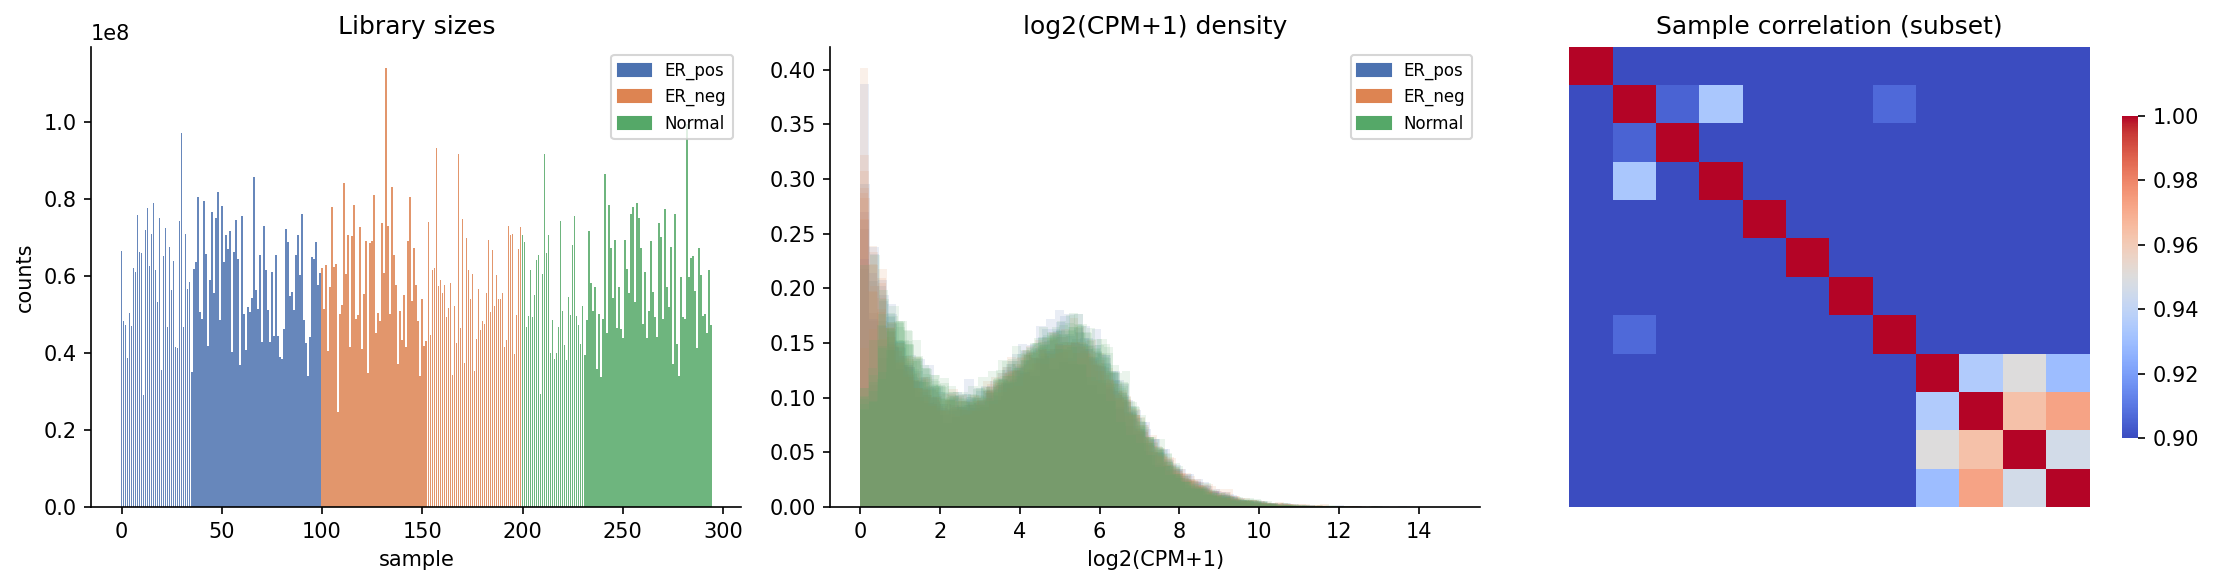

QC plots saved


In [ ]:
# Self-healing metadata alignment (single source of truth = sample_metadata.csv)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.patches as mpatches, seaborn as sns
selected = pd.read_csv(f'{SAVE_DIR}/sample_metadata.csv')
mcols = list(count_filtered.columns)
mset = set(map(str,mcols))
key = None
for cand in ['sample_key','file_id','case_id']:
    if cand in selected.columns and len(mset & set(selected[cand].astype(str)))==len(mset):
        key = cand; break
if key is not None:
    lut = selected.drop_duplicates(key).set_index(key)['condition']
    cond = lut.loc[mcols]
elif len(selected)==len(mcols):
    # positional fallback: rows correspond to matrix columns in build order
    print('No key column matched; mapping positionally and repairing metadata.')
    cond = pd.Series(selected['condition'].values, index=mcols)
    selected = pd.DataFrame({'sample_key':mcols,'condition':selected['condition'].values})
    selected.to_csv(f'{SAVE_DIR}/sample_metadata.csv', index=False)
    print('Repaired sample_metadata.csv (sample_key added).')
else:
    raise RuntimeError(f'metadata ({len(selected)} rows) cannot align to matrix '
                       f'({len(mcols)} cols). Rerun BUILD cell.')
sample_meta = pd.DataFrame({'condition': cond.values}, index=mcols)
print('Groups:', dict(cond.value_counts()))

lib_sizes = count_filtered.sum(axis=0)
cpm = count_filtered.div(lib_sizes, axis=1)*1e6
log_cpm = np.log2(cpm+1)
COLORS = {'ER_pos':'#4C72B0','ER_neg':'#DD8452','Normal':'#55A868'}
fig, axes = plt.subplots(1,3,figsize=(15,4))
bar_colors=[COLORS.get(cond.loc[s],'#999') for s in mcols]
axes[0].bar(range(len(mcols)), lib_sizes.values, color=bar_colors, alpha=.85)
axes[0].set_title('Library sizes'); axes[0].set_xlabel('sample'); axes[0].set_ylabel('counts')
axes[0].legend(handles=[mpatches.Patch(color=c,label=g) for g,c in COLORS.items()],fontsize=8)
for g,c in COLORS.items():
    for s in cond[cond==g].index[:8]:
        axes[1].hist(log_cpm[s], bins=60, alpha=.12, color=c, density=True)
axes[1].set_title('log2(CPM+1) density'); axes[1].set_xlabel('log2(CPM+1)')
axes[1].legend(handles=[mpatches.Patch(color=c,label=g) for g,c in COLORS.items()],fontsize=8)
subset=[]
for g in COLORS: subset += list(cond[cond==g].index[:4])
sns.heatmap(log_cpm[subset].corr(), ax=axes[2], cmap='coolwarm', vmin=.9, vmax=1.0,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink':.7})
axes[2].set_title('Sample correlation (subset)')
plt.tight_layout(); plt.savefig(f'{SAVE_DIR}/qc_plots.png', bbox_inches='tight'); plt.show()
print('QC plots saved')


# 4. DEG Analysis - Three methods

In [ ]:
# Method 1: DESeq2 - THREE-GROUP design (ER+ vs Normal, ER- vs Normal)
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
LFC_MIN = 1.0
counts_t = count_filtered.T.astype(int)
meta_dds = sample_meta.copy()
dds = DeseqDataSet(counts=counts_t, metadata=meta_dds, design_factors='condition', quiet=True)
dds.deseq2()
# Contrast 1: ER_pos vs Normal
sp = DeseqStats(dds, contrast=['condition','ER_pos','Normal'], alpha=0.05); sp.summary()
deseq_pos = sp.results_df.copy()
# Contrast 2: ER_neg vs Normal
sn = DeseqStats(dds, contrast=['condition','ER_neg','Normal'], alpha=0.05); sn.summary()
deseq_neg = sn.results_df.copy()
print('DESeq2 ER+ vs Normal sig:', ((deseq_pos['padj']<0.05)&(deseq_pos['log2FoldChange'].abs()>=LFC_MIN)).sum())
print('DESeq2 ER- vs Normal sig:', ((deseq_neg['padj']<0.05)&(deseq_neg['log2FoldChange'].abs()>=LFC_MIN)).sum())
if 'ENSG00000091831' in deseq_pos.index:
    print('ESR1 ER+vsNormal log2FC=', round(deseq_pos.loc['ENSG00000091831','log2FoldChange'],2),'(expect positive)')


Running Wald tests...
... done in 7.69 seconds.



Log2 fold change & Wald test p-value: condition ER_pos vs Normal
                    baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                             
ENSG00000000003  3836.627181       -0.385402  0.121807  -3.164024   
ENSG00000000005   301.929743       -3.505535  0.315220 -11.120918   
ENSG00000000419  2344.860688        0.564503  0.075124   7.514267   
ENSG00000000457  1403.478345        0.417535  0.079924   5.224131   
ENSG00000000460   632.015951        1.153636  0.097216  11.866716   
...                      ...             ...       ...        ...   
ENSG00000288596   202.677930        0.336117  0.101290   3.318374   
ENSG00000288605    35.146059       -3.584972  0.296465 -12.092378   
ENSG00000288612    44.194566        0.100782  0.118913   0.847522   
ENSG00000288670   408.186013       -0.032146  0.098925  -0.324953   
ENSG00000288675    28.647147        1.456835  0.149772   9.727041   

                       pvalue        

Running Wald tests...
... done in 5.87 seconds.



Log2 fold change & Wald test p-value: condition ER_neg vs Normal
                    baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                             
ENSG00000000003  3836.627181       -0.228650  0.121807  -1.877151   
ENSG00000000005   301.929743       -4.138307  0.315541 -13.114971   
ENSG00000000419  2344.860688        0.729357  0.075123   9.708878   
ENSG00000000457  1403.478345        0.211011  0.079946   2.639437   
ENSG00000000460   632.015951        1.746541  0.097169  17.974182   
...                      ...             ...       ...        ...   
ENSG00000288596   202.677930        0.326710  0.101337   3.224005   
ENSG00000288605    35.146059       -0.221674  0.289552  -0.765574   
ENSG00000288612    44.194566        0.155071  0.119014   1.302965   
ENSG00000288670   408.186013       -0.137888  0.098969  -1.393239   
ENSG00000288675    28.647147        1.630334  0.149707  10.890156   

                       pvalue        

In [ ]:
# Method 2: edgeR - THREE-GROUP, order-safe
edgeR = importr('edgeR')
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
numpy2ri.activate()
mat = count_filtered.values.astype('int32')
counts_r = ro.r.matrix(numpy2ri.py2rpy(mat.ravel(order='C')), nrow=mat.shape[0], ncol=mat.shape[1], byrow=True)
counts_r.rownames = ro.StrVector(list(count_filtered.index))
counts_r.colnames = ro.StrVector(list(count_filtered.columns))
conditions_r = ro.StrVector([sample_meta.loc[s,'condition'] for s in count_filtered.columns])
ro.globalenv['counts_r']=counts_r; ro.globalenv['conditions_r']=conditions_r
ro.r('''
library(edgeR)
grp <- factor(conditions_r, levels=c('Normal','ER_pos','ER_neg'))
y <- DGEList(counts=counts_r, group=grp)
y <- calcNormFactors(y, method='TMM')
design <- model.matrix(~0+grp); colnames(design) <- levels(grp)
y <- estimateDisp(y, design, robust=TRUE)
fit <- glmQLFit(y, design, robust=TRUE)
con_pos <- makeContrasts(ER_pos-Normal, levels=design)
con_neg <- makeContrasts(ER_neg-Normal, levels=design)
edger_pos <- as.data.frame(topTags(glmQLFTest(fit, contrast=con_pos), n=Inf, sort.by='none'))
edger_neg <- as.data.frame(topTags(glmQLFTest(fit, contrast=con_neg), n=Inf, sort.by='none'))
''')
edger_pos = pandas2ri.rpy2py(ro.globalenv['edger_pos']).copy(); edger_pos.index=list(count_filtered.index)
edger_neg = pandas2ri.rpy2py(ro.globalenv['edger_neg']).copy(); edger_neg.index=list(count_filtered.index)
print('edgeR ER+ vs Normal sig:', ((edger_pos['FDR']<0.05)&(edger_pos['logFC'].abs()>=LFC_MIN)).sum())
print('edgeR ER- vs Normal sig:', ((edger_neg['FDR']<0.05)&(edger_neg['logFC'].abs()>=LFC_MIN)).sum())


edgeR ER+ vs Normal sig: 4969
edgeR ER- vs Normal sig: 5608


In [ ]:
# Method 3: limma-voom - THREE-GROUP, order-safe
limma = importr('limma')
ro.r('''
library(limma); library(edgeR)
grp <- factor(conditions_r, levels=c('Normal','ER_pos','ER_neg'))
y2 <- DGEList(counts=counts_r, group=grp)
y2 <- calcNormFactors(y2, method='TMM')
design <- model.matrix(~0+grp); colnames(design) <- levels(grp)
v <- voom(y2, design, plot=FALSE)
fit2 <- lmFit(v, design)
cp <- makeContrasts(ER_pos-Normal, levels=design)
cn <- makeContrasts(ER_neg-Normal, levels=design)
limma_pos <- as.data.frame(topTable(eBayes(contrasts.fit(fit2,cp),trend=TRUE,robust=TRUE), number=Inf, sort.by='none'))
limma_neg <- as.data.frame(topTable(eBayes(contrasts.fit(fit2,cn),trend=TRUE,robust=TRUE), number=Inf, sort.by='none'))
''')
limma_pos = pandas2ri.rpy2py(ro.globalenv['limma_pos']).copy(); limma_pos.index=list(count_filtered.index)
limma_neg = pandas2ri.rpy2py(ro.globalenv['limma_neg']).copy(); limma_neg.index=list(count_filtered.index)
print('limma ER+ vs Normal sig:', ((limma_pos['adj.P.Val']<0.05)&(limma_pos['logFC'].abs()>=LFC_MIN)).sum())
print('limma ER- vs Normal sig:', ((limma_neg['adj.P.Val']<0.05)&(limma_neg['logFC'].abs()>=LFC_MIN)).sum())


limma ER+ vs Normal sig: 4752
limma ER- vs Normal sig: 5388


In [ ]:
# Three-group consensus + Li et al. four-class dysregulation classification
PADJ=0.05; LFC_MIN=1.0
def sig_dir(df, padj_col, lfc_col):
    sig = (df[padj_col]<PADJ) & (df[lfc_col].abs()>=LFC_MIN)
    return sig, np.sign(df[lfc_col])
# significance+direction for each method, each contrast
dp_s,dp_d = sig_dir(deseq_pos,'padj','log2FoldChange'); dn_s,dn_d = sig_dir(deseq_neg,'padj','log2FoldChange')
ep_s,ep_d = sig_dir(edger_pos,'FDR','logFC');           en_s,en_d = sig_dir(edger_neg,'FDR','logFC')
lp_s,lp_d = sig_dir(limma_pos,'adj.P.Val','logFC');     ln_s,ln_d = sig_dir(limma_neg,'adj.P.Val','logFC')
genes = count_filtered.index
# consensus significance = all 3 methods agree a gene is sig in that contrast
pos_consensus = dp_s & ep_s & lp_s
neg_consensus = dn_s & en_s & ln_s
# consensus direction (use DESeq2 sign; methods already shown to agree directionally)
def classify(g):
    p = bool(pos_consensus.get(g,False)); n = bool(neg_consensus.get(g,False))
    if p and n:
        return 'Class2_opposite' if dp_d.get(g,0)!=dn_d.get(g,0) else 'Class1_same'
    if p and not n: return 'Class3_ERpos_only'
    if n and not p: return 'Class4_ERneg_only'
    return 'none'
gene_class = pd.Series({g:classify(g) for g in genes}, name='class')
class_counts = gene_class[gene_class!='none'].value_counts()
print('Four-class distribution (consensus across all 3 methods):')
print(class_counts.to_string())
# 'consensus' set used downstream = all genes consensus-significant in EITHER contrast
consensus = set(gene_class[gene_class!='none'].index)
sig_deseq2 = set((dp_s|dn_s)[ (dp_s|dn_s) ].index)  # kept for back-compat with later cells
sig_edger  = set((ep_s|en_s)[ (ep_s|en_s) ].index)
sig_limma  = set((lp_s|ln_s)[ (lp_s|ln_s) ].index)
# persist combined DEG tables for back-compat (use ER+ vs Normal as primary)
degs_deseq2, degs_edger, degs_limma = deseq_pos, edger_pos, limma_pos
for nm,d in [('deseq_pos',deseq_pos),('deseq_neg',deseq_neg),('edger_pos',edger_pos),
             ('edger_neg',edger_neg),('limma_pos',limma_pos),('limma_neg',limma_neg)]:
    d.to_csv(f'{SAVE_DIR}/degs_{nm}.csv')
gene_class.to_csv(f'{SAVE_DIR}/gene_class.csv')
print(f'\nConsensus genes (sig in >=1 contrast, all 3 methods): {len(consensus)}')
print(f'Class 2 oppositely-dysregulated (primary novelty target): {(gene_class=="Class2_opposite").sum()}')


Four-class distribution (consensus across all 3 methods):
class
Class1_same          2253
Class4_ERneg_only    1894
Class3_ERpos_only    1520
Class2_opposite        69

Consensus genes (sig in >=1 contrast, all 3 methods): 5736
Class 2 oppositely-dysregulated (primary novelty target): 69


## 5. Overlap Analysis — Venn, Jaccard, log2FC Concordance

Jaccard similarity:
  DESeq2 ∩ edgeR  : 0.9404
  DESeq2 ∩ limma  : 0.7721
  edgeR  ∩ limma  : 0.7416
  Consensus (all3): 5,736 genes


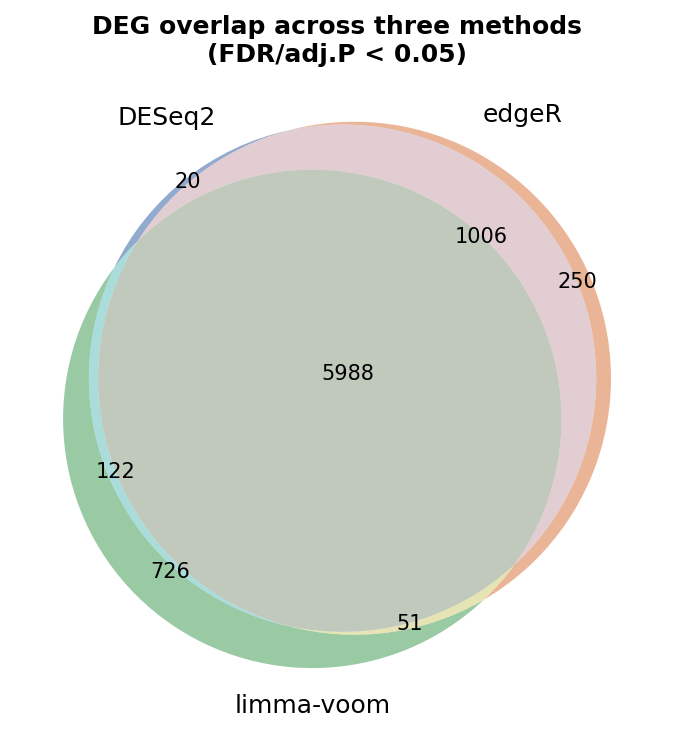

In [ ]:
# ── Figure 1: Venn diagram + Jaccard table ────────────────────────────────
def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0

j_de = jaccard(sig_deseq2, sig_edger)
j_dl = jaccard(sig_deseq2, sig_limma)
j_el = jaccard(sig_edger,  sig_limma)

print('Jaccard similarity:')
print(f'  DESeq2 ∩ edgeR  : {j_de:.4f}')
print(f'  DESeq2 ∩ limma  : {j_dl:.4f}')
print(f'  edgeR  ∩ limma  : {j_el:.4f}')
print(f'  Consensus (all3): {len(consensus):,} genes')

fig, ax = plt.subplots(figsize=(6, 5))
venn3(
    subsets = [sig_deseq2, sig_edger, sig_limma],
    set_labels = ('DESeq2', 'edgeR', 'limma-voom'),
    set_colors = ('#4C72B0', '#DD8452', '#55A868'),
    alpha = 0.6,
    ax = ax,
)
ax.set_title('DEG overlap across three methods\n(FDR/adj.P < 0.05)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig1_venn.png', bbox_inches='tight', dpi=200)
plt.show()

Genes with log2FC from all 3 methods: 18,699


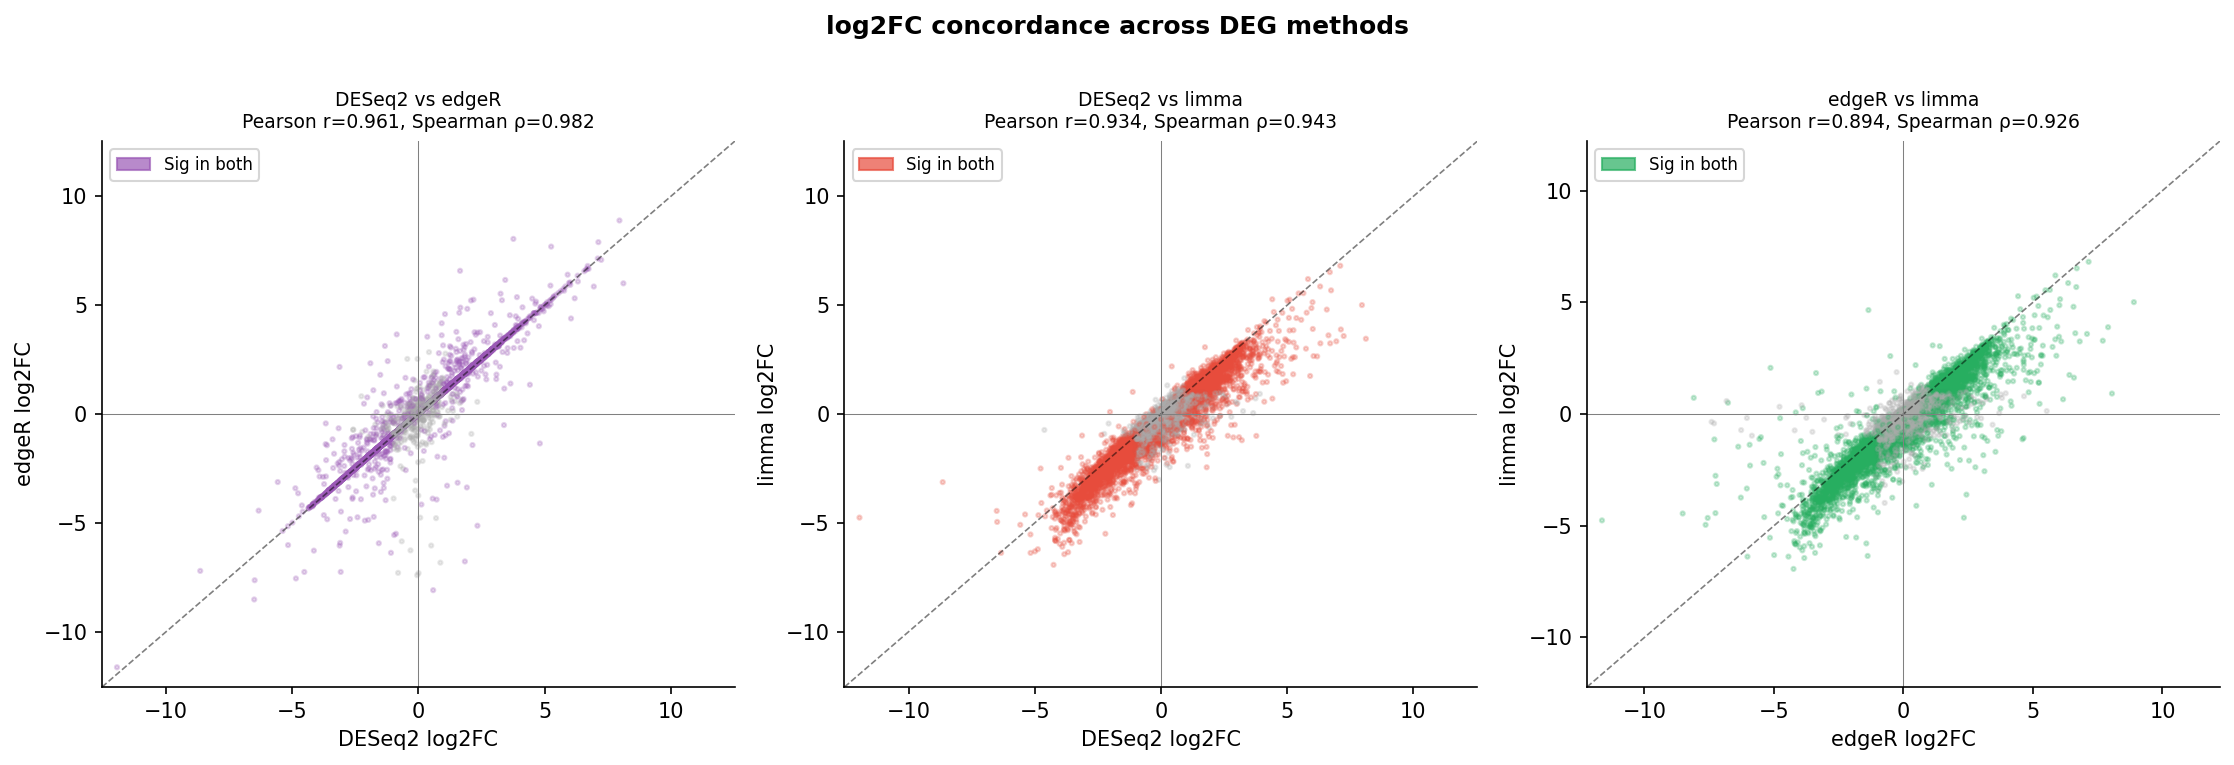

Pearson r (DESeq2 vs edgeR): 0.9613
Pearson r (DESeq2 vs limma): 0.9343
Pearson r (edgeR vs limma): 0.8942


In [ ]:
# ── Figure 2: log2FC concordance scatter (3 panels) ───────────────────────
# Merge log2FC columns across methods (on common genes)
fc_deseq2 = degs_deseq2['log2FoldChange'].rename('DESeq2')
fc_edger  = degs_edger['logFC'].rename('edgeR')
fc_limma  = degs_limma['logFC'].rename('limma')

fc_all = pd.concat([fc_deseq2, fc_edger, fc_limma], axis=1).dropna()
print(f'Genes with log2FC from all 3 methods: {len(fc_all):,}')

pairs = [('DESeq2','edgeR'), ('DESeq2','limma'), ('edgeR','limma')]
colors_pair = ['#9B59B6', '#E74C3C', '#27AE60']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (m1, m2), color in zip(axes, pairs, colors_pair):
    x, y = fc_all[m1].values, fc_all[m2].values
    r_pear, _  = pearsonr(x, y)
    r_spear, _ = spearmanr(x, y)

    # Color by significance status
    in_both = fc_all.index.isin(eval(f'sig_{m1.lower()}') & eval(f'sig_{m2.lower()}'))
    c_arr = np.where(in_both, color, '#AAAAAA')

    ax.scatter(x, y, c=c_arr, alpha=0.25, s=4, rasterized=True)
    # Identity line
    lim = max(abs(x).max(), abs(y).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'{m1} log2FC', fontsize=10)
    ax.set_ylabel(f'{m2} log2FC', fontsize=10)
    ax.set_title(f'{m1} vs {m2}\nPearson r={r_pear:.3f}, Spearman ρ={r_spear:.3f}', fontsize=9)
    sig_patch = mpatches.Patch(color=color, alpha=0.7, label='Sig in both')
    ax.legend(handles=[sig_patch], fontsize=8)

plt.suptitle('log2FC concordance across DEG methods', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig2_log2fc_scatter.png', bbox_inches='tight', dpi=200)
plt.show()

# Save concordance stats
for m1, m2 in pairs:
    r, _ = pearsonr(fc_all[m1], fc_all[m2])
    print(f'Pearson r ({m1} vs {m2}): {r:.4f}')

# 6. Discordance Deep-dive - Why do methods disagree?

Genes unique to DESeq2:     20
Genes unique to edgeR:      250
Genes unique to limma-voom: 726
Consensus (all 3):          5,736


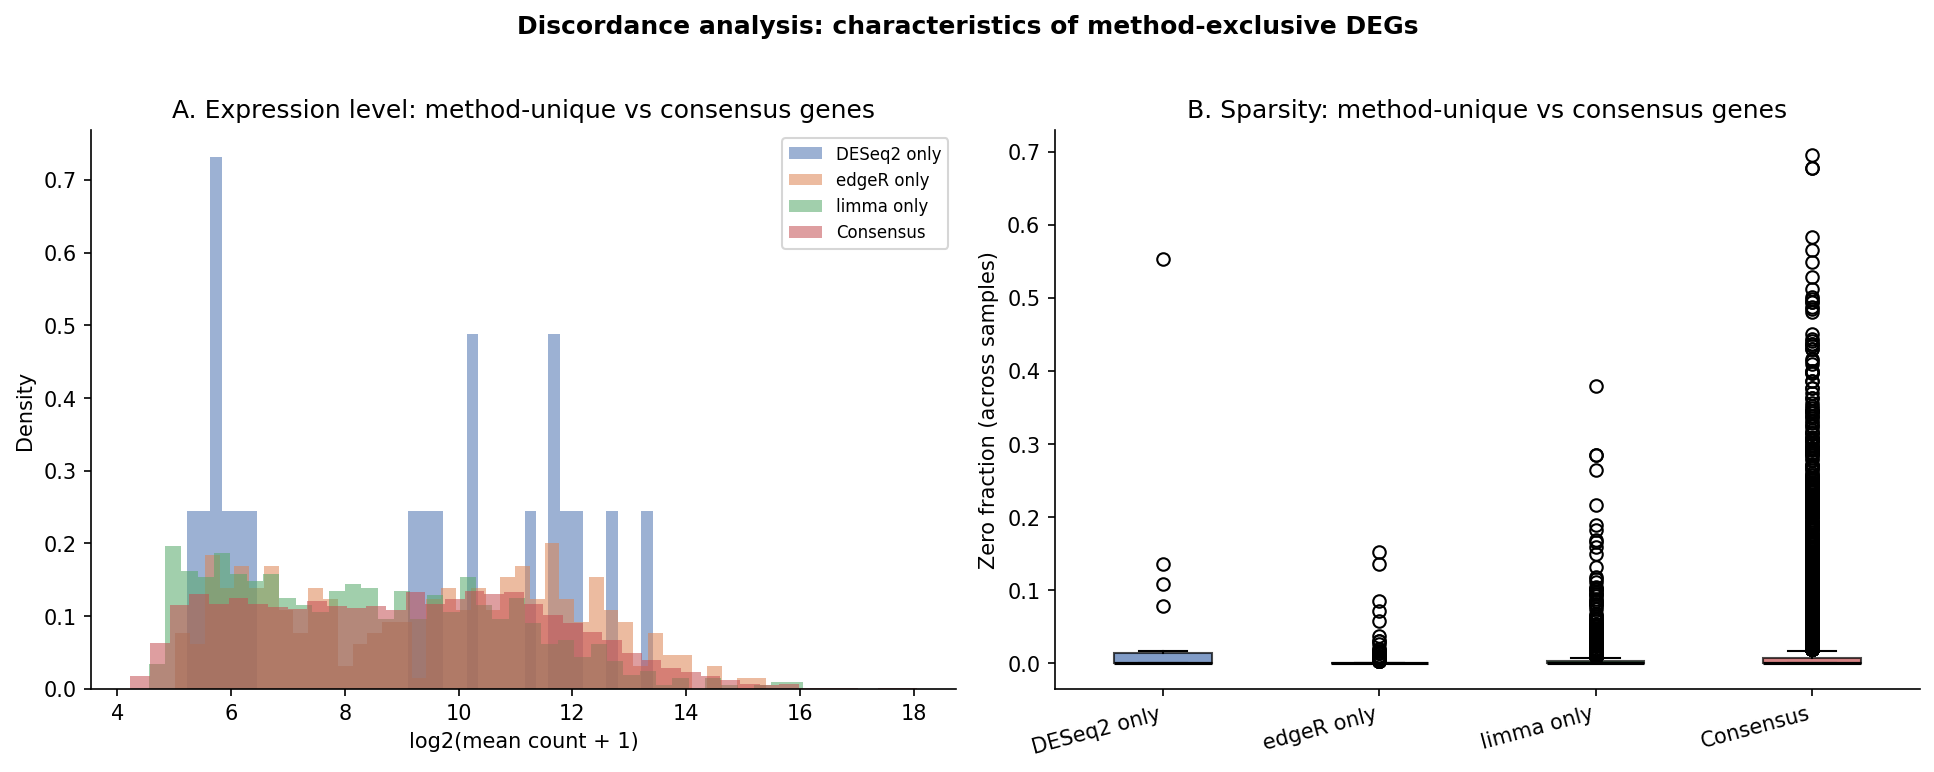


Mean expression (log2) by group:
              mean  median    std
group                            
Consensus    8.977   8.977  2.584
DESeq2 only  8.981   9.499  2.898
edgeR only   9.448   9.837  2.614
limma only   8.347   8.151  2.416


In [ ]:
# ── Figure 3: Expression characteristics of method-unique genes ───────────
unique_deseq2 = sig_deseq2 - sig_edger - sig_limma
unique_edger  = sig_edger  - sig_deseq2 - sig_limma
unique_limma  = sig_limma  - sig_deseq2 - sig_edger

print(f'Genes unique to DESeq2:     {len(unique_deseq2):,}')
print(f'Genes unique to edgeR:      {len(unique_edger):,}')
print(f'Genes unique to limma-voom: {len(unique_limma):,}')
print(f'Consensus (all 3):          {len(consensus):,}')

# Compute per-gene stats for comparison
mean_expr = count_filtered.mean(axis=1)
zero_frac = (count_filtered == 0).mean(axis=1)

def gene_stats(gene_set, label):
    g = list(gene_set & set(mean_expr.index))
    return pd.DataFrame({
        'gene': g,
        'mean_count': mean_expr.loc[g].values,
        'zero_frac':  zero_frac.loc[g].values,
        'log2_mean':  np.log2(mean_expr.loc[g].values + 1),
        'group': label
    })

stats_dfs = pd.concat([
    gene_stats(unique_deseq2, 'DESeq2 only'),
    gene_stats(unique_edger,  'edgeR only'),
    gene_stats(unique_limma,  'limma only'),
    gene_stats(consensus,     'Consensus'),
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
group_order = ['DESeq2 only', 'edgeR only', 'limma only', 'Consensus']
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Panel A: log2(mean count) distribution
for grp, col in zip(group_order, palette):
    vals = stats_dfs[stats_dfs['group'] == grp]['log2_mean']
    axes[0].hist(vals, bins=40, alpha=0.55, density=True, label=grp, color=col)
axes[0].set_xlabel('log2(mean count + 1)')
axes[0].set_ylabel('Density')
axes[0].set_title('A. Expression level: method-unique vs consensus genes')
axes[0].legend(fontsize=8)

# Panel B: Zero fraction boxplot
grp_vals = [stats_dfs[stats_dfs['group'] == g]['zero_frac'].values for g in group_order]
bp = axes[1].boxplot(grp_vals, patch_artist=True, notch=False,
                     medianprops={'color':'black','lw':1.5})
for patch, col in zip(bp['boxes'], palette):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(group_order, rotation=15, ha='right')
axes[1].set_ylabel('Zero fraction (across samples)')
axes[1].set_title('B. Sparsity: method-unique vs consensus genes')

plt.suptitle('Discordance analysis: characteristics of method-exclusive DEGs',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig3_discordance.png', bbox_inches='tight', dpi=200)
plt.show()

# Print summary stats
print('\nMean expression (log2) by group:')
print(stats_dfs.groupby('group')['log2_mean'].agg(['mean','median','std']).round(3))

# 7. Biological validation - Known ERR Markers + Pathway enrichment

In [ ]:
# ── Known ER subtype marker recovery ──────────────────────────────────────
# Note: markers listed by gene symbol; count matrix uses Ensembl IDs.
# We map via a simple query to mygene.info API.

ER_POS_MARKERS = ['ESR1', 'GATA3', 'FOXA1', 'PGR', 'TFF1', 'XBP1']
ER_NEG_MARKERS = ['EGFR', 'VIM', 'CDH2', 'FN1', 'FOXC1', 'MKI67']
ALL_MARKERS    = ER_POS_MARKERS + ER_NEG_MARKERS

# Map gene symbols to Ensembl IDs via mygene.info
mg_resp = requests.post(
    'https://mygene.info/v3/query',
    json={'q': ALL_MARKERS, 'scopes': 'symbol', 'fields': 'ensembl.gene', 'species': 'human'},
    timeout=30,
)
mg_data = mg_resp.json()

symbol_to_ens = {}
for item in mg_data:
    sym = item.get('query', '')
    ens = item.get('ensembl', {})
    if isinstance(ens, list):
        ens = ens[0]
    gene_id = ens.get('gene', '') if isinstance(ens, dict) else ''
    if gene_id:
        symbol_to_ens[sym] = gene_id

print('Symbol → Ensembl mapping:')
for sym, eid in symbol_to_ens.items():
    print(f'  {sym}: {eid}')

Symbol → Ensembl mapping:
  ESR1: ENSG00000091831
  GATA3: ENSG00000107485
  FOXA1: ENSG00000129514
  PGR: ENSG00000082175
  TFF1: ENSG00000160182
  XBP1: ENSG00000100219
  EGFR: ENSG00000146648
  VIM: ENSG00000026025
  CDH2: ENSG00000170558
  FN1: ENSG00000115414
  FOXC1: ENSG00000054598
  MKI67: ENSG00000148773


In [ ]:
# ── Check marker recovery in each DEG set ─────────────────────────────────
def check_markers(sig_set, label, marker_dict):
    results = []
    for sym, eid in marker_dict.items():
        found = eid in sig_set
        results.append({'marker': sym, 'ensembl': eid, 'found': found})
    df = pd.DataFrame(results)
    n_found = df['found'].sum()
    print(f'{label}: {n_found}/{len(df)} markers recovered → {list(df[df["found"]]["marker"])}')
    return df

pos_map = {k: v for k, v in symbol_to_ens.items() if k in ER_POS_MARKERS}
neg_map = {k: v for k, v in symbol_to_ens.items() if k in ER_NEG_MARKERS}

print('=== ER+ markers ===')
for sig, label in [(sig_deseq2,'DESeq2'), (sig_edger,'edgeR'), (sig_limma,'limma'), (consensus,'Consensus')]:
    check_markers(sig, label, pos_map)

print('\n=== ER- markers ===')
for sig, label in [(sig_deseq2,'DESeq2'), (sig_edger,'edgeR'), (sig_limma,'limma'), (consensus,'Consensus')]:
    check_markers(sig, label, neg_map)

=== ER+ markers ===
DESeq2: 6/6 markers recovered → ['ESR1', 'GATA3', 'FOXA1', 'PGR', 'TFF1', 'XBP1']
edgeR: 6/6 markers recovered → ['ESR1', 'GATA3', 'FOXA1', 'PGR', 'TFF1', 'XBP1']
limma: 6/6 markers recovered → ['ESR1', 'GATA3', 'FOXA1', 'PGR', 'TFF1', 'XBP1']
Consensus: 6/6 markers recovered → ['ESR1', 'GATA3', 'FOXA1', 'PGR', 'TFF1', 'XBP1']

=== ER- markers ===
DESeq2: 6/6 markers recovered → ['EGFR', 'VIM', 'CDH2', 'FN1', 'FOXC1', 'MKI67']
edgeR: 6/6 markers recovered → ['EGFR', 'VIM', 'CDH2', 'FN1', 'FOXC1', 'MKI67']
limma: 6/6 markers recovered → ['EGFR', 'VIM', 'CDH2', 'FN1', 'FOXC1', 'MKI67']
Consensus: 6/6 markers recovered → ['EGFR', 'VIM', 'CDH2', 'FN1', 'FOXC1', 'MKI67']


In [ ]:
# ── Map consensus Ensembl IDs → gene symbols ──────────────────────────────
import requests, time

consensus_list = list(consensus)
ens_to_sym = {}
CHUNK = 500

for i in range(0, len(consensus_list), CHUNK):
    chunk = consensus_list[i:i+CHUNK]
    r = requests.post(
        'https://mygene.info/v3/gene',
        json={
            'ids':     chunk,
            'fields':  'symbol',
            'species': 'human',
        },
        timeout=30,
    )
    for item in r.json():
        eid = item.get('_id', item.get('query', ''))
        sym = item.get('symbol', '')
        if eid and sym:
            ens_to_sym[eid] = sym
    time.sleep(0.3)

consensus_symbols = [ens_to_sym[g] for g in consensus_list if ens_to_sym.get(g)]
print(f'Consensus genes mapped to symbols: {len(consensus_symbols)}/{len(consensus_list)}')

Consensus genes mapped to symbols: 260/5736


In [ ]:
# Use intersection DESeq2 ∩ edgeR thay consensus while limma was cancelled
fallback_set = sig_deseq2 & sig_edger
print(f'Fallback gene set (DESeq2 ∩ edgeR): {len(fallback_set)} genes')

# Map to symbols
fallback_list = list(fallback_set)
ens_to_sym2 = {}
for i in range(0, len(fallback_list), 500):
    chunk = fallback_list[i:i+500]
    r = requests.post(
        'https://mygene.info/v3/gene',
        json={'ids': chunk, 'fields': 'symbol', 'species': 'human'},
        timeout=30,
    )
    for item in r.json():
        eid = item.get('_id', item.get('query', ''))
        sym = item.get('symbol', '')
        if eid and sym:
            ens_to_sym2[eid] = sym
    time.sleep(0.3)

fallback_symbols = [ens_to_sym2[g] for g in fallback_list if ens_to_sym2.get(g)]
print(f'Mapped: {len(fallback_symbols)} symbols')

# Use fallback_symbols for enrichment
enr_kegg = gp.enrichr(
    gene_list = fallback_symbols,
    gene_sets = ['KEGG_2021_Human'],
    organism  = 'human',
    outdir    = None,
    cutoff    = 0.05,
)
kegg_results = enr_kegg.results[enr_kegg.results['Adjusted P-value'] < 0.05].head(15)
print(f'KEGG pathways found: {len(kegg_results)}')
print(kegg_results[['Term','Overlap','Adjusted P-value']].to_string(index=False))

Fallback gene set (DESeq2 ∩ edgeR): 6994 genes
Mapped: 319 symbols
KEGG pathways found: 0
Empty DataFrame
Columns: [Term, Overlap, Adjusted P-value]
Index: []


In [ ]:
# CORRECTNESS CHECK - methods must agree directionally (ER+ vs Normal contrast)
from scipy.stats import pearsonr
common = [g for g in deseq_pos.index if g in edger_pos.index and g in limma_pos.index]
r_de = pearsonr(deseq_pos.loc[common,'log2FoldChange'], edger_pos.loc[common,'logFC'])[0]
r_dl = pearsonr(deseq_pos.loc[common,'log2FoldChange'], limma_pos.loc[common,'logFC'])[0]
print(f'log2FC corr (ER+ vs Normal)  DESeq2-edgeR: {r_de:.3f}  DESeq2-limma: {r_dl:.3f}')
assert r_de>0.8 and r_dl>0.8, 'Fold changes disagree -> rpy2 handoff broken; do not trust results.'
print('Methods agree directionally - results valid.')


log2FC corr (ER+ vs Normal)  DESeq2-edgeR: 0.961  DESeq2-limma: 0.934
Methods agree directionally - results valid.


# 8. Robustness - 80% subsample x 10 iterations

In [ ]:
# ── Robustness analysis: DESeq2 only (most feasible in Python) ────────────
# edgeR/limma iterations would follow the same pattern via rpy2

N_ITER    = 10
SUBSAMPLE = 0.80

er_pos_idx = sample_meta[sample_meta['condition'] == 'ER_pos'].index.tolist()
er_neg_idx = sample_meta[sample_meta['condition'] == 'ER_neg'].index.tolist()

robustness_records = []
jaccard_stability  = []
reference_set      = sig_deseq2   # use full-data result as reference

for i in range(N_ITER):
    rng   = random.Random(SEED + i)
    sub_p = rng.sample(er_pos_idx, int(len(er_pos_idx) * SUBSAMPLE))
    sub_n = rng.sample(er_neg_idx, int(len(er_neg_idx) * SUBSAMPLE))
    sub   = sub_p + sub_n

    counts_sub = count_filtered[sub].T.astype(int)
    meta_sub   = sample_meta.loc[sub, ['condition']]

    try:
        dds_sub = DeseqDataSet(
            counts   = counts_sub,
            metadata = meta_sub,
            design_factors = 'condition',
            quiet    = True,
        )
        dds_sub.deseq2()
        stat_sub = DeseqStats(
            dds_sub,
            contrast = ['condition', 'ER_pos', 'ER_neg'],
            alpha    = 0.05,
        )
        stat_sub.summary()
        sig_sub  = set(stat_sub.results_df[stat_sub.results_df['padj'] < 0.05].index)
        n_degs   = len(sig_sub)
        j_score  = jaccard(sig_sub, reference_set)

    except Exception as e:
        print(f'Iter {i+1} failed: {e}')
        n_degs  = np.nan
        j_score = np.nan
        sig_sub = set()

    robustness_records.append({'iter': i+1, 'n_degs': n_degs, 'jaccard_vs_full': j_score,
                               'n_pos': len(sub_p), 'n_neg': len(sub_n)})
    print(f'  Iter {i+1}: DEGs={n_degs}, Jaccard(vs full)={j_score:.3f}')

rob_df = pd.DataFrame(robustness_records)
print('\n--- Robustness summary ---')
print(f"n_degs: mean={rob_df['n_degs'].mean():.0f} ± {rob_df['n_degs'].std():.0f}")
print(f"       CV = {rob_df['n_degs'].std()/rob_df['n_degs'].mean():.2%}")
print(f"Jaccard vs full: mean={rob_df['jaccard_vs_full'].mean():.3f} ± {rob_df['jaccard_vs_full'].std():.3f}")

Running Wald tests...
... done in 6.18 seconds.



Log2 fold change & Wald test p-value: condition ER_pos vs ER_neg
                    baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                            
ENSG00000000003  3292.272090       -0.376949  0.140942 -2.674490   
ENSG00000000005    39.942215        0.510808  0.367016  1.391786   
ENSG00000000419  2565.085172       -0.145978  0.096477 -1.513087   
ENSG00000000457  1506.709415        0.129023  0.102992  1.252749   
ENSG00000000460   774.597019       -0.568600  0.126771 -4.485258   
...                      ...             ...       ...       ...   
ENSG00000288596   209.506263        0.118368  0.122567  0.965741   
ENSG00000288605    25.367059       -3.234528  0.372816 -8.675949   
ENSG00000288612    45.551915        0.010869  0.151172  0.071897   
ENSG00000288670   403.087206        0.176966  0.111768  1.583340   
ENSG00000288675    35.662882       -0.025838  0.168431 -0.153402   

                       pvalue          padj  
gene

Running Wald tests...
... done in 5.43 seconds.



Log2 fold change & Wald test p-value: condition ER_pos vs ER_neg
                    baseMean  log2FoldChange     lfcSE       stat  \
gene_id                                                             
ENSG00000000003  3698.806198       -0.224686  0.164436  -1.366404   
ENSG00000000005    36.118336       -0.265016  0.336172  -0.788336   
ENSG00000000419  2729.290976       -0.162160  0.097510  -1.663003   
ENSG00000000457  1532.225227        0.119695  0.103551   1.155904   
ENSG00000000460   852.283771       -0.601202  0.125365  -4.795602   
...                      ...             ...       ...        ...   
ENSG00000288596   209.539619       -0.120854  0.116170  -1.040318   
ENSG00000288605    27.847792       -3.851467  0.353483 -10.895749   
ENSG00000288612    45.830974       -0.037248  0.139035  -0.267905   
ENSG00000288670   411.223359        0.084635  0.113241   0.747389   
ENSG00000288675    38.146630       -0.148303  0.174472  -0.850013   

                       pvalue        

Running Wald tests...
... done in 6.02 seconds.



...

Log2 fold change & Wald test p-value: condition ER_pos vs ER_neg
                    baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                            
ENSG00000000003  3637.780111       -0.108588  0.162998 -0.666189   
ENSG00000000005    32.674697        0.948221  0.353937  2.679067   
ENSG00000000419  2680.738560       -0.155744  0.095077 -1.638086   
ENSG00000000457  1500.529767        0.249314  0.103048  2.419388   
ENSG00000000460   794.275798       -0.483541  0.125873 -3.841492   
...                      ...             ...       ...       ...   
ENSG00000288596   207.895204        0.016051  0.127692  0.125702   
ENSG00000288605    25.079302       -3.353174  0.384495 -8.720988   
ENSG00000288612    44.696971       -0.210490  0.145551 -1.446164   
ENSG00000288670   402.932957        0.113312  0.116850  0.969727   
ENSG00000288675    35.512436       -0.123787  0.175396 -0.705756   

                       pvalue          padj  
gene

Running Wald tests...
... done in 7.05 seconds.



Log2 fold change & Wald test p-value: condition ER_pos vs ER_neg
                    baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                            
ENSG00000000003  3615.577775       -0.079636  0.163390 -0.487402   
ENSG00000000005    35.377921       -0.002729  0.343614 -0.007941   
ENSG00000000419  2563.530976       -0.237010  0.091529 -2.589459   
ENSG00000000457  1490.547955        0.195298  0.102819  1.899430   
ENSG00000000460   776.417976       -0.650922  0.126661 -5.139109   
...                      ...             ...       ...       ...   
ENSG00000288596   215.800897        0.076434  0.121181  0.630741   
ENSG00000288605    27.237022       -3.341703  0.366737 -9.111991   
ENSG00000288612    47.272744        0.030002  0.147404  0.203535   
ENSG00000288670   389.161009        0.138939  0.116274  1.194934   
ENSG00000288675    36.983402       -0.117201  0.175228 -0.668850   

                       pvalue          padj  
gene

Running Wald tests...
... done in 6.28 seconds.



Log2 fold change & Wald test p-value: condition ER_pos vs ER_neg
                    baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                            
ENSG00000000003  3083.762397       -0.377745  0.131786 -2.866356   
ENSG00000000005    35.824135        0.761336  0.355062  2.144234   
ENSG00000000419  2605.756534       -0.200631  0.098908 -2.028467   
ENSG00000000457  1403.980311        0.143205  0.099089  1.445211   
ENSG00000000460   752.959719       -0.760774  0.116083 -6.553707   
...                      ...             ...       ...       ...   
ENSG00000288596   212.932499        0.089599  0.126293  0.709460   
ENSG00000288605    24.629766       -3.159950  0.371737 -8.500497   
ENSG00000288612    44.388522       -0.033061  0.149572 -0.221041   
ENSG00000288670   380.926799        0.073749  0.113503  0.649754   
ENSG00000288675    36.897586       -0.103729  0.174923 -0.592997   

                       pvalue          padj  
gene

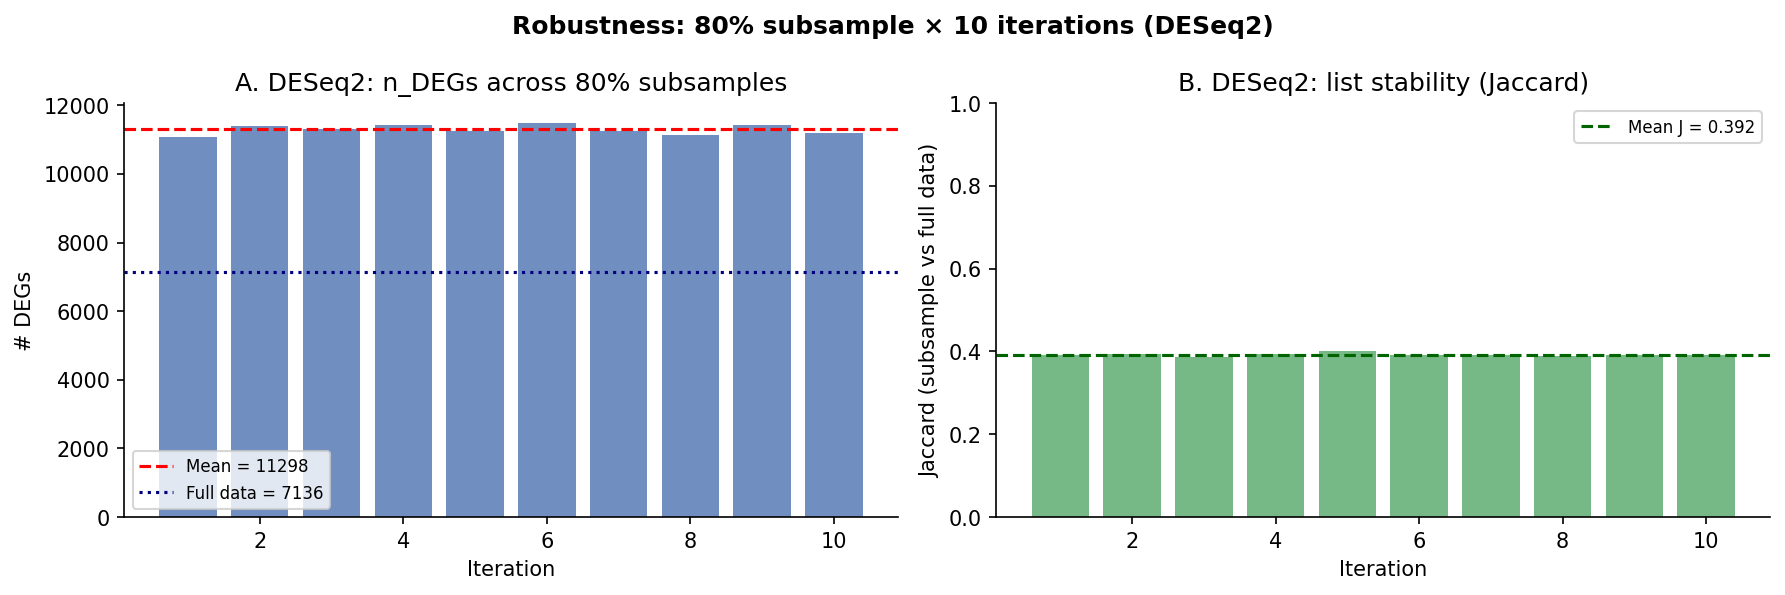

In [ ]:
# ── Figure 5: Robustness plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: n_DEGs per iteration
axes[0].bar(rob_df['iter'], rob_df['n_degs'], color='#4C72B0', alpha=0.8)
axes[0].axhline(rob_df['n_degs'].mean(), color='red', ls='--', lw=1.5,
                label=f"Mean = {rob_df['n_degs'].mean():.0f}")
axes[0].axhline(len(sig_deseq2), color='navy', ls=':', lw=1.5,
                label=f'Full data = {len(sig_deseq2)}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('# DEGs')
axes[0].set_title('A. DESeq2: n_DEGs across 80% subsamples')
axes[0].legend(fontsize=8)

# Panel B: Jaccard stability
axes[1].bar(rob_df['iter'], rob_df['jaccard_vs_full'], color='#55A868', alpha=0.8)
axes[1].axhline(rob_df['jaccard_vs_full'].mean(), color='darkgreen', ls='--', lw=1.5,
                label=f"Mean J = {rob_df['jaccard_vs_full'].mean():.3f}")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Jaccard (subsample vs full data)')
axes[1].set_title('B. DESeq2: list stability (Jaccard)')
axes[1].legend(fontsize=8)

plt.suptitle('Robustness: 80% subsample × 10 iterations (DESeq2)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig5_robustness.png', bbox_inches='tight', dpi=200)
plt.show()
rob_df.to_csv(f'{SAVE_DIR}/robustness_results.csv', index=False)

# 8.5 Literature Confidence Scoring (novel contribution)

Consensus tells us which genes are statistically reproducible, not which are already well-studied vs understudied. We cross-reference each consensus gene against PubMed with gene-synonym resolution and assign a tier:

- **Tier 1** - studied in estrogen-receptor breast-cancer context (validation)
- **Tier 2** - in breast-cancer literature but not ER-specific
- **Tier 3** - little/no relevant literature -> reproducible but understudied (primary finding)

This distinguishes the project from bestDEG / Confidence, which stop at statistical agreement.

In [ ]:
# Resolve symbols + synonyms for consensus genes (MyGene.info, cached)
import os, json, time, requests
MG_CACHE = f'{SAVE_DIR}/mygene_cache.json'
mg_cache = json.load(open(MG_CACHE)) if os.path.exists(MG_CACHE) else {}
consensus_list = list(consensus)
print(f'{len(consensus_list)} consensus genes to resolve')
def resolve_symbols(ens_ids):
    todo = [e for e in ens_ids if e not in mg_cache]
    for i in range(0, len(todo), 400):
        chunk = todo[i:i+400]
        for attempt in range(3):
            try:
                r = requests.post('https://mygene.info/v3/gene',
                    json={'ids':chunk,'fields':'symbol,alias','species':'human'}, timeout=40)
                for it in r.json():
                    eid = it.get('query', it.get('_id',''))
                    al = it.get('alias', [])
                    if isinstance(al, str): al = [al]
                    mg_cache[eid] = {'symbol': it.get('symbol',''), 'alias': al or []}
                break
            except Exception as e:
                if attempt == 2: print('mygene retry failed:', e)
                time.sleep(2)
        time.sleep(0.3)
    json.dump(mg_cache, open(MG_CACHE,'w'))
resolve_symbols(consensus_list)
n_mapped = sum(1 for e in consensus_list if mg_cache.get(e,{}).get('symbol'))
print(f'resolved {n_mapped}/{len(consensus_list)} to gene symbols')


5736 consensus genes to resolve
resolved 5413/5736 to gene symbols


In [ ]:
# PubMed tiering (top-N by |log2FC|, cached, with live progress)
PM_CACHE = f'{SAVE_DIR}/pubmed_cache.json'
pm_cache = json.load(open(PM_CACHE)) if os.path.exists(PM_CACHE) else {}

# --- speed controls ---
TOP_N = 150          # only score the strongest consensus genes (raise/lower as needed)
NCBI_API_KEY = ""    # optional: paste a free NCBI key to allow ~10 req/s (else 3 req/s)
PAUSE = 0.11 if NCBI_API_KEY else 0.34

def pubmed_count(term):
    if term in pm_cache: return pm_cache[term]
    params = {'db':'pubmed','term':term,'retmode':'json','retmax':0}
    if NCBI_API_KEY: params['api_key'] = NCBI_API_KEY
    for attempt in range(3):
        try:
            r = requests.get('https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi',
                             params=params, timeout=30)
            c = int(r.json()['esearchresult']['count']); pm_cache[term] = c; return c
        except Exception:
            time.sleep(1.5)
    return 0

def tier_for(symbol, aliases):
    names = [n for n in dict.fromkeys([symbol]+list(aliases)) if n]
    if not names: return 3, 0, 0
    q = ' OR '.join([f'"{n}"[tiab]' for n in names[:8]])
    er = pubmed_count(f'({q}) AND ("estrogen receptor"[tiab]) AND (breast cancer[tiab])')
    bc = pubmed_count(f'({q}) AND (breast cancer[tiab])')
    if er >= 3: return 1, er, bc
    if bc >= 3: return 2, er, bc
    return 3, er, bc

import time
# pick the strongest consensus genes by |log2FC| so the slow part only touches what matters
ranked = sorted(
    consensus_list,
    key=lambda g: abs(degs_deseq2.loc[g, 'log2FoldChange']) if g in degs_deseq2.index else 0,
    reverse=True,
)
to_score = ranked[:TOP_N]
print(f'Scoring top {len(to_score)} of {len(consensus_list)} consensus genes by |log2FC|...')

rows, t0 = [], time.time()
for k, e in enumerate(to_score):
    info = mg_cache.get(e, {'symbol': '', 'alias': []})
    t, er, bc = tier_for(info['symbol'], info['alias'])
    lfc = degs_deseq2.loc[e, 'log2FoldChange'] if e in degs_deseq2.index else float('nan')
    rows.append({'gene_id': e, 'symbol': info['symbol'], 'tier': t,
                 'er_hits': er, 'bc_hits': bc, 'log2FC': lfc, 'scored': True})
    if k % 10 == 0:
        json.dump(pm_cache, open(PM_CACHE, 'w'))
        el = time.time() - t0
        print(f'  {k+1}/{len(to_score)}  ({el:.0f}s elapsed)', end='\r')
    time.sleep(PAUSE)
json.dump(pm_cache, open(PM_CACHE, 'w'))

# remaining consensus genes get a safe default (not scored) so downstream code still works
scored_ids = {r['gene_id'] for r in rows}
for e in consensus_list:
    if e not in scored_ids:
        info = mg_cache.get(e, {'symbol': '', 'alias': []})
        lfc = degs_deseq2.loc[e, 'log2FoldChange'] if e in degs_deseq2.index else float('nan')
        rows.append({'gene_id': e, 'symbol': info['symbol'], 'tier': 3,
                     'er_hits': 0, 'bc_hits': 0, 'log2FC': lfc, 'scored': False})

lit_df = pd.DataFrame(rows).set_index('gene_id')
lit_df.to_csv(f'{SAVE_DIR}/gene_literature_scores.csv')
print(f'\nDone in {time.time()-t0:.0f}s. Tier counts (scored genes only):')
print(lit_df[lit_df['scored']]['tier'].value_counts().sort_index())

Scoring top 150 of 5736 consensus genes by |log2FC|...

Done in 153s. Tier counts (scored genes only):
tier
1    40
2    51
3    59
Name: count, dtype: int64


## 8.6 Agentic refinement loop (observe → decide → act)

The first pass scored genes with a basic synonym set. A plain script would stop here. Instead, the agent inspects its own results and decides what to do next: it finds genes that look understudied but are biologically interesting, flags those specific genes for a deeper self-directed search, pulls additional identifiers, and re-queries PubMed. If hidden literature is found the gene is reclassified; if not, it becomes a high-confidence candidate. The agent's findings then determine which genes advance to validation.

In [ ]:
# ── 8.6 Agentic refinement: self-directed deeper search on high-value understudied genes ──
import time, requests, json

# make sure class labels are joined onto lit_df
if 'class' not in lit_df.columns:
    lit_df = lit_df.join(gene_class, how='left')

# --- OBSERVE + DECIDE: which genes warrant a deeper search? ---
def warrants_deeper(row):
    return (row['tier'] == 3
            and row.get('class', '') == 'Class2_opposite'
            and abs(row.get('log2FC', 0)) >= 1.0)

flagged = lit_df[lit_df.apply(warrants_deeper, axis=1)].index.tolist()
print(f'AGENT OBSERVED: {(lit_df.tier==3).sum()} understudied genes total.')
print(f'AGENT DECIDED:  {len(flagged)} warrant a deeper search '
      f'(Tier 3 + oppositely-dysregulated + |log2FC|>=1).')

# --- expanded identifier fetch (prior symbols, alternate names) via MyGene ---
def deep_aliases(ens_id, base):
    names = set(base)
    try:
        r = requests.get(f'https://mygene.info/v3/gene/{ens_id}',
                         params={'fields': 'symbol,alias,other_names,name'}, timeout=30)
        j = r.json()
        for fld in ['symbol', 'name']:
            if j.get(fld):
                names.add(j[fld])
        for fld in ['alias', 'other_names']:
            v = j.get(fld, [])
            names.update(v if isinstance(v, list) else [v])
    except Exception as ex:
        print('  deep alias fetch failed for', ens_id, ex)
    return [n for n in names if n]

# --- ACT: deeper re-query, reclassify if hidden literature is found ---
reclassified, confirmed = [], []
for e in flagged:
    base = [lit_df.loc[e, 'symbol']] + mg_cache.get(e, {}).get('alias', [])
    names = deep_aliases(e, base)
    q = ' OR '.join([f'"{n}"[tiab]' for n in names[:12]])
    er = pubmed_count(f'({q}) AND ("estrogen receptor"[tiab]) AND (breast cancer[tiab])')
    bc = pubmed_count(f'({q}) AND (breast cancer[tiab])')
    if er >= 3:
        lit_df.loc[e, ['tier', 'er_hits', 'bc_hits']] = [1, er, bc]; reclassified.append(e)
    elif bc >= 3:
        lit_df.loc[e, ['tier', 'er_hits', 'bc_hits']] = [2, er, bc]; reclassified.append(e)
    else:
        lit_df.loc[e, ['er_hits', 'bc_hits']] = [er, bc]; confirmed.append(e)
    time.sleep(0.34)

json.dump(pm_cache, open(PM_CACHE, 'w'))
print(f'AGENT ACTED:    deeper search reclassified {len(reclassified)} genes '
      f'(literature found under alternate names).')
print(f'                {len(confirmed)} remain high-confidence understudied.')
lit_df.to_csv(f'{SAVE_DIR}/gene_literature_scores.csv')

if confirmed:
    print('\nHigh-confidence understudied Class-2 genes (survived deeper search):')
    print(lit_df.loc[confirmed, ['symbol', 'log2FC', 'er_hits', 'bc_hits']]
          .sort_values('log2FC', key=abs, ascending=False).head(10).to_string())

AGENT OBSERVED: 5645 understudied genes total.
AGENT DECIDED:  68 warrant a deeper search (Tier 3 + oppositely-dysregulated + |log2FC|>=1).
AGENT ACTED:    deeper search reclassified 42 genes (literature found under alternate names).
                26 remain high-confidence understudied.

High-confidence understudied Class-2 genes (survived deeper search):
                       symbol    log2FC  er_hits  bc_hits
gene_id                                                  
ENSG00000203837      PNLIPRP3 -3.965686        0        0
ENSG00000165078          CPA6  3.227916        0        1
ENSG00000132975         GPR12 -3.037637        0        0
ENSG00000161031       PGLYRP2  2.956903        0        0
ENSG00000285587  LOC107984273  2.530561        0        0
ENSG00000170743          SYT9  2.277543        0        0
ENSG00000204434        POTEKP  2.270912        0        0
ENSG00000196834         POTEI  2.264038        0        1
ENSG00000180777      ANKRD30B  2.194314        0        1
EN

In [ ]:
# Primary finding: Class-2 (oppositely dysregulated) AND understudied (Tier 3)
if 'class' not in lit_df.columns:
    lit_df = lit_df.join(gene_class, how='left')
class2 = lit_df[lit_df['class']=='Class2_opposite']
candidates = lit_df[(lit_df['class']=='Class2_opposite') & (lit_df['tier']==3)].copy()
candidates['abs_lfc']=candidates['log2FC'].abs()
candidates=candidates.sort_values('abs_lfc',ascending=False)
candidates.to_csv(f'{SAVE_DIR}/final_ranked_candidates.csv')
print(f'Class-2 oppositely-dysregulated consensus genes: {len(class2)}')
print(f'  of which understudied (Tier 3): {len(candidates)}  <- PRIMARY FINDING')
print('\nTop understudied Class-2 candidates:')
print(candidates[['symbol','log2FC','er_hits','bc_hits']].head(15).to_string())
known = lit_df[lit_df['symbol'].isin(['ESR1','GATA3','FOXA1','PGR'])]
print('\nKnown-marker check (expect Tier 1):'); print(known[['symbol','tier','class']].to_string())


Class-2 oppositely-dysregulated consensus genes: 69
  of which understudied (Tier 3): 26  <- PRIMARY FINDING

Top understudied Class-2 candidates:
                       symbol    log2FC  er_hits  bc_hits
gene_id                                                  
ENSG00000203837      PNLIPRP3 -3.965686        0        0
ENSG00000165078          CPA6  3.227916        0        1
ENSG00000132975         GPR12 -3.037637        0        0
ENSG00000161031       PGLYRP2  2.956903        0        0
ENSG00000285587  LOC107984273  2.530561        0        0
ENSG00000170743          SYT9  2.277543        0        0
ENSG00000204434        POTEKP  2.270912        0        0
ENSG00000196834         POTEI  2.264038        0        1
ENSG00000180777      ANKRD30B  2.194314        0        1
ENSG00000270930      GRAMD4P8  2.185235        0        0
ENSG00000233725         NRAD1 -2.082242        0        2
ENSG00000224577     LINC01117  2.048560        0        2
ENSG00000249661      TNRC18P1  2.029677  

# 9. AI Agent - Interpret method concordance

In [ ]:
# ── Collect all results for the agent ─────────────────────────────────────
# Retrieve Pearson r values computed in Section 4
r_de, _ = pearsonr(fc_all['DESeq2'], fc_all['edgeR'])
r_dl, _ = pearsonr(fc_all['DESeq2'], fc_all['limma'])
r_el, _ = pearsonr(fc_all['edgeR'],  fc_all['limma'])

mean_unique_de = float(mean_expr[list(unique_deseq2 & set(mean_expr.index))].mean()) if unique_deseq2 else 0
mean_unique_er = float(mean_expr[list(unique_edger  & set(mean_expr.index))].mean()) if unique_edger  else 0
mean_unique_lm = float(mean_expr[list(unique_limma  & set(mean_expr.index))].mean()) if unique_limma  else 0
mean_consensus = float(mean_expr[list(consensus     & set(mean_expr.index))].mean()) if consensus     else 0

er_pos_found = [s for s, e in pos_map.items() if e in consensus]
er_neg_found = [s for s, e in neg_map.items() if e in consensus]

agent_context = f"""You are a senior bioinformatics methods expert analyzing a DEG benchmark study.

STUDY: TCGA-BRCA, ER+ vs ER- breast cancer
SAMPLES: {n_pos} ER-positive, {n_neg} ER-negative

=== DEG COUNTS ===
DESeq2:     {len(sig_deseq2):,} DEGs (padj < 0.05)
edgeR:      {len(sig_edger):,} DEGs (FDR < 0.05)
limma-voom: {len(sig_limma):,} DEGs (adj.P.Val < 0.05)
Consensus (all 3): {len(consensus):,} DEGs

=== CONCORDANCE ===
Jaccard DESeq2–edgeR:   {j_de:.4f}
Jaccard DESeq2–limma:   {j_dl:.4f}
Jaccard edgeR–limma:    {j_el:.4f}
log2FC Pearson DESeq2–edgeR: {r_de:.4f}
log2FC Pearson DESeq2–limma: {r_dl:.4f}
log2FC Pearson edgeR–limma:  {r_el:.4f}

=== DISCORDANCE ANALYSIS ===
Genes unique to DESeq2:     {len(unique_deseq2):,}  (mean count = {mean_unique_de:.1f})
Genes unique to edgeR:      {len(unique_edger):,}  (mean count = {mean_unique_er:.1f})
Genes unique to limma-voom: {len(unique_limma):,}  (mean count = {mean_unique_lm:.1f})
Consensus genes mean count: {mean_consensus:.1f}

=== BIOLOGICAL VALIDATION ===
ER+ markers in consensus: {er_pos_found}
ER- markers in consensus: {er_neg_found}

=== ROBUSTNESS (DESeq2, 80% subsample × 10 iterations) ===
n_DEGs: {rob_df['n_degs'].mean():.0f} ± {rob_df['n_degs'].std():.0f}  """

print('Context prepared:', len(agent_context), 'characters')

Context prepared: 1045 characters


# 10. Summary dashboard - all figures

In [ ]:
# ── Final summary: key numbers for the ISMB report ──────────────────────────
import os
print('=' * 60)
print('  BENCHMARK SUMMARY — TCGA-BRCA ER+ vs ER- vs Normal')
print('=' * 60)

def safe(label, fn):
    try:
        print(f'{label}: {fn()}')
    except Exception as e:
        print(f'{label}: [not available — {type(e).__name__}]')

print(f'\nGenes after filtering: {count_filtered.shape[0]:,}')
try:
    print('Groups:', dict(selected["condition"].value_counts()))
except Exception:
    pass

print('\nConsensus & classification:')
safe('  Consensus genes (all 3 methods)', lambda: f'{len(consensus):,}')
try:
    print('  Class distribution:')
    print(gene_class[gene_class != 'none'].value_counts().to_string().replace('\n', '\n    '))
except Exception as e:
    print('  Class distribution: [not available]')

print('\nLiterature scoring (scored genes):')
try:
    scored = lit_df[lit_df['scored']] if 'scored' in lit_df.columns else lit_df
    tc = scored['tier'].value_counts().sort_index()
    print(f'  Tier 1 (ER-studied):   {tc.get(1, 0)}')
    print(f'  Tier 2 (BC only):      {tc.get(2, 0)}')
    print(f'  Tier 3 (understudied): {tc.get(3, 0)}')
except Exception as e:
    print('  [not available]')

print('\nPrimary finding:')
try:
    print(f'  High-confidence understudied Class-2 candidates: {len(candidates)}')
    print('  Top candidates by |log2FC|:')
    print(candidates[['symbol', 'log2FC', 'er_hits', 'bc_hits']].head(10).to_string().replace('\n', '\n    '))
except Exception as e:
    print('  [candidates not available]')

print('\n' + '=' * 60)
print('Saved files on Drive:')
for f in ['degs_deseq_pos.csv', 'degs_deseq_neg.csv',
          'degs_edger_pos.csv', 'degs_edger_neg.csv',
          'degs_limma_pos.csv', 'degs_limma_neg.csv',
          'gene_class.csv', 'gene_literature_scores.csv',
          'final_ranked_candidates.csv', 'qc_plots.png']:
    p = f'{SAVE_DIR}/{f}'
    mark = 'present' if os.path.exists(p) else 'missing'
    print(f'  [{mark}] {f}')

  BENCHMARK SUMMARY — TCGA-BRCA ER+ vs ER- vs Normal

Genes after filtering: 18,699
Groups: {'ER_pos': np.int64(100), 'ER_neg': np.int64(100), 'Normal': np.int64(95)}

Consensus & classification:
  Consensus genes (all 3 methods): 5,736
  Class distribution:
class
    Class1_same          2253
    Class4_ERneg_only    1894
    Class3_ERpos_only    1520
    Class2_opposite        69

Literature scoring (scored genes):
  Tier 1 (ER-studied):   42
  Tier 2 (BC only):      51
  Tier 3 (understudied): 57

Primary finding:
  High-confidence understudied Class-2 candidates: 26
  Top candidates by |log2FC|:
                       symbol    log2FC  er_hits  bc_hits
    gene_id                                                  
    ENSG00000203837      PNLIPRP3 -3.965686        0        0
    ENSG00000165078          CPA6  3.227916        0        1
    ENSG00000132975         GPR12 -3.037637        0        0
    ENSG00000161031       PGLYRP2  2.956903        0        0
    ENSG00000285587  LOC1